# Atividade 2.2 — Método de Iteração de Ponto Fixo

**Aluno:** Vinicius Batista Duarte

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import scipy.optimize as opt
import time

print("SciPy:", scipy.__version__)

SciPy: 1.17.0


### 1. Implemente o algoritmo da iteração de ponto fixo usando somente a biblioteca Numpy.

In [2]:
def ponto_fixo_numpy(g, x0, tol=1e-10, max_iter=200):
    """Iteração simples de ponto fixo usando somente NumPy."""
    x_atual = x0

    for i in range(1, max_iter + 1):
        x_novo = g(x_atual)

        if x_novo != 0:
            erro_relativo = np.abs((x_novo - x_atual) / x_novo)

            if erro_relativo <= tol:
                return x_novo, i, True

        x_atual = x_novo

    return x_atual, max_iter, False

### 2. Use a iteração de ponto fixo simples para localizar a raiz

Considere:

$$
f(x)=2\sin(\sqrt{x})-x
$$

com $x_0=0.5$ e erro $e_a\leq0.001\%$.

Primeiro, escrevemos a equação na forma $x=g(x)$:

$$
2\sin(\sqrt{x})-x=0
\Rightarrow
x=2\sin(\sqrt{x})
$$

Portanto,

$$
g(x)=2\sin(\sqrt{x}).
$$

Como a questão pede **iteração simples**, usamos `method='iteration'` em `opt.fixed_point`, seguindo a distinção feita no material.

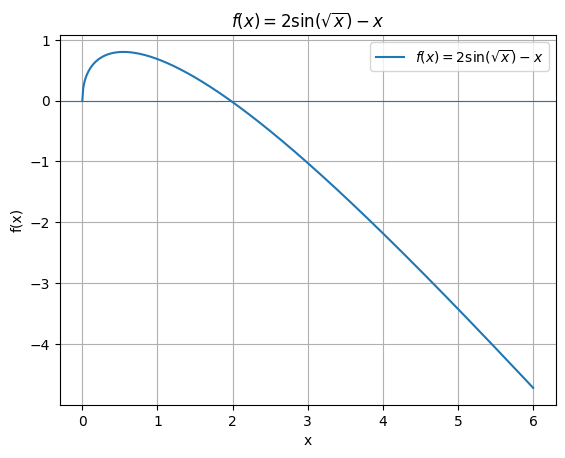

In [3]:
f2 = lambda x: 2 * np.sin(np.sqrt(x)) - x
g2 = lambda x: 2 * np.sin(np.sqrt(x))

x = np.linspace(0, 6, 500)

plt.plot(x, f2(x), label=r"$f(x)=2\sin(\sqrt{x})-x$")
plt.axhline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f(x)=2\sin(\sqrt{x})-x$")
plt.grid()
plt.legend()
plt.show()

In [4]:
# 0.001% = 0.001/100 = 1e-5
tol_q2 = 0.001 / 100

raiz_q2 = opt.fixed_point(
    g2,
    0.5,
    xtol=tol_q2,
    maxiter=200,
    method='iteration'
)

print(f"Raiz encontrada: {raiz_q2:.10f}")
print(f"f(raiz) = {f2(raiz_q2):.2e}")

Raiz encontrada: 1.9723804861
f(raiz) = 4.52e-07


### 3. Determine a maior raiz real de

$$
f(x)=2x^3-11.7x^2+17.7x-5
$$

#### a) Graficamente

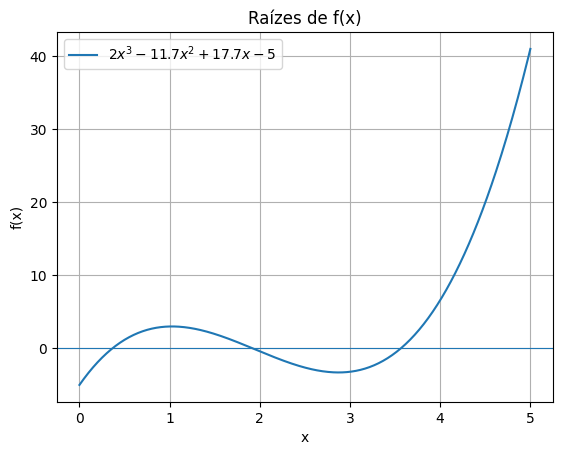

In [5]:
f3 = lambda x: 2*x**3 - 11.7*x**2 + 17.7*x - 5

x = np.linspace(0, 5, 500)

plt.plot(x, f3(x), label=r"$2x^3-11.7x^2+17.7x-5$")
plt.axhline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Raízes de f(x)")
plt.grid()
plt.legend()
plt.show()

Pelo gráfico, a maior raiz está aproximadamente em $x\approx3.5$. Assim, usamos o intervalo $[3,4]$ para a bisseção.

#### b) Método da Bisseção — 5 iterações

In [6]:
resultado_biss_q3 = opt.root_scalar(
    f3,
    method='bisect',
    bracket=[3, 4],
    xtol=1e-15,
    maxiter=5
)

print(f"Raiz após 5 iterações: {resultado_biss_q3.root:.10f}")
print(f"f(x) = {f3(resultado_biss_q3.root):.6e}")
print(f"Iterações: {resultado_biss_q3.iterations}")
print(f"Convergiu: {resultado_biss_q3.converged}")
print(f"Flag: {resultado_biss_q3.flag}")

Raiz após 5 iterações: 3.5625000000
f(x) = -6.933594e-03
Iterações: 5
Convergiu: False
Flag: convergence error


#### c) Método da Iteração de Ponto Fixo — 5 iterações, $x_0=3$

Isolando $x$:

$$
2x^3-11.7x^2+17.7x-5=0
$$

$$
17.7x=5-2x^3+11.7x^2
$$

$$
x=g(x)=\frac{5-2x^3+11.7x^2}{17.7}.
$$

Como são **5 iterações**, vamos usar `opt.fixed_point` com `maxiter=5`. Como a tolerância não é atingida nesse número de iterações, a função gera `RuntimeError`. Para não perder o resultado, registramos os valores passados à função durante a execução.

In [7]:
g3 = lambda x: (5 - 2*x**3 + 11.7*x**2) / 17.7

valores = [3.0]

def g3_registrada(x):
    novo = g3(x)
    valores.append(novo)
    return novo

try:
    opt.fixed_point(
        g3_registrada,
        3,
        xtol=1e-15,
        maxiter=5,
        method='iteration'
    )
except RuntimeError as erro:
    print("O método não atingiu a tolerância em 5 iterações.")
    print("A última aproximação foi registrada abaixo.")

tabela_q3 = pd.DataFrame({
    "Iteração": range(len(valores)),
    "x": valores
})

tabela_q3

O método não atingiu a tolerância em 5 iterações.
A última aproximação foi registrada abaixo.


,Iteração,x
0,0,3.000000
1,1,3.180791
2,2,3.333959
3,3,3.442543
4,4,3.506330
5,5,3.538294


# 4. Comparação entre Bisseção, Falsa Posição e Ponto Fixo

Configurações:
- tolerância: $10^{-10}$;
- máximo de iterações: 200;
- ponto inicial do Ponto Fixo: limite inferior do intervalo.

In [8]:
TOL = 1e-10
MAX_ITER = 200

def falsa_posicao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    """Método da Falsa Posição (Regula Falsi)."""
    fa = f(a)
    fb = f(b)

    if fa * fb >= 0:
        return None, 0, False

    for i in range(1, max_iter + 1):
        x = b - fb * (a - b) / (fa - fb)
        fx = f(x)

        if abs(fx) <= tol:
            return x, i, True

        if fa * fx < 0:
            b, fb = x, fx
        else:
            a, fa = x, fx

    return x, max_iter, False

In [9]:
def resolver_bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    try:
        r = opt.root_scalar(
            f,
            method='bisect',
            bracket=[a, b],
            xtol=tol,
            maxiter=max_iter
        )
        return r.root, r.iterations, r.converged
    except ValueError:
        return None, 0, False


def resolver_ponto_fixo(g, x0, tol=TOL, max_iter=MAX_ITER):
    try:
        raiz = opt.fixed_point(
            g,
            x0,
            xtol=tol,
            maxiter=max_iter,
            method='iteration'
        )
        return float(raiz), None, True
    except RuntimeError:
        return None, max_iter, False


def comparar_metodos(f, g, a, b, nome_funcao):
    resultados = []

    # Bisseção via scipy.optimize
    inicio = time.perf_counter()
    raiz, it, conv = resolver_bissecao(f, a, b)
    tempo = time.perf_counter() - inicio
    resultados.append(["Bisseção", raiz, it, conv, tempo])

    # Falsa Posição manual (não há método Regula Falsi em root_scalar)
    inicio = time.perf_counter()
    raiz, it, conv = falsa_posicao(f, a, b)
    tempo = time.perf_counter() - inicio
    resultados.append(["Falsa Posição", raiz, it, conv, tempo])

    # Ponto Fixo via scipy.optimize
    inicio = time.perf_counter()
    raiz, it, conv = resolver_ponto_fixo(g, a)
    tempo = time.perf_counter() - inicio
    resultados.append(["Ponto Fixo", raiz, it, conv, tempo])

    tabela = pd.DataFrame(
        resultados,
        columns=["Método", "Raiz", "Iterações", "Convergiu", "Tempo (s)"]
    )

    print(f"Função: {nome_funcao}")
    display(tabela)
    return tabela

## a) $f_1(x)=2x^4+4x^3+3x^2-10x-15$, com $x^*\in[0,3]$

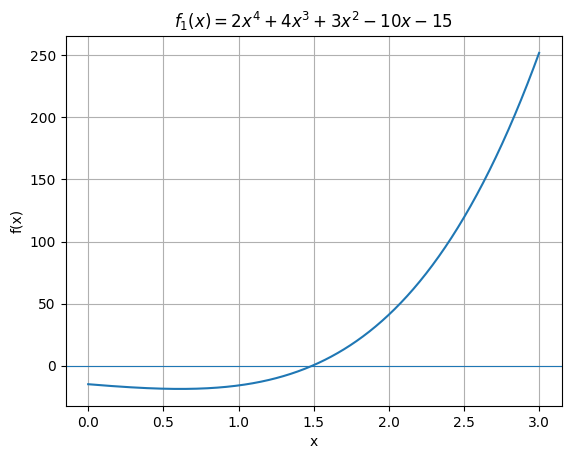

Função: $2x^4+4x^3+3x^2-10x-15$


,Método,Raiz,Iterações,Convergiu,Tempo (s)
0,Bisseção,1.492879,35.0,True,0.000750
1,Falsa Posição,1.492879,78.0,True,0.000038
2,Ponto Fixo,-1.300384,NaN,True,0.001560


In [10]:
f1_q4 = lambda x: 2*x**4 + 4*x**3 + 3*x**2 - 10*x - 15

x = np.linspace(0, 3, 500)
plt.plot(x, f1_q4(x))
plt.axhline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f_1(x)=2x^4+4x^3+3x^2-10x-15$")
plt.grid()
plt.show()

# Isolamento usado para o ponto fixo:
# x = (2x^4 + 4x^3 + 3x^2 - 15)/10
g1_q4 = lambda x: (2*x**4 + 4*x**3 + 3*x**2 - 15) / 10

tabela_f1 = comparar_metodos(
    f1_q4, g1_q4, 0, 3,
    r"$2x^4+4x^3+3x^2-10x-15$"
)

## b) $f_2(x)=(x+3)(x+1)(x-2)^3$, com $x^*\in[0,5]$

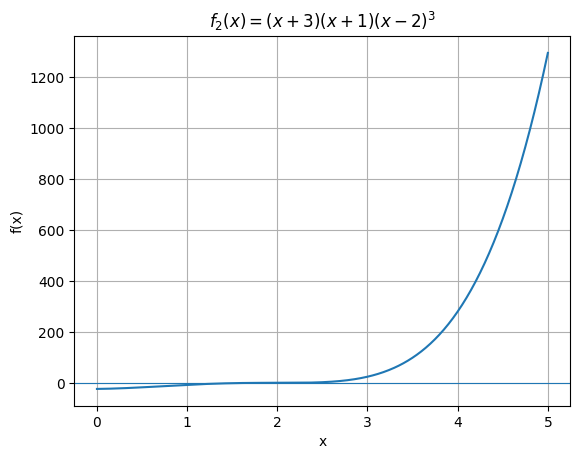

Função: $(x+3)(x+1)(x-2)^3$


,Método,Raiz,Iterações,Convergiu,Tempo (s)
0,Bisseção,2.000000,36,True,0.000096
1,Falsa Posição,1.714409,200,False,0.000059
2,Ponto Fixo,NaN,200,False,0.007514


In [11]:
f2_q4 = lambda x: (x + 3) * (x + 1) * (x - 2)**3

x = np.linspace(0, 5, 500)
plt.plot(x, f2_q4(x))
plt.axhline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f_2(x)=(x+3)(x+1)(x-2)^3$")
plt.grid()
plt.show()

# Escolha de g(x) = x - alpha*f(x), com alpha pequeno.
alpha2 = 1e-4
g2_q4 = lambda x: x - alpha2 * f2_q4(x)

tabela_f2 = comparar_metodos(
    f2_q4, g2_q4, 0, 5,
    r"$(x+3)(x+1)(x-2)^3$"
)

## c) $f_3(x)=5x^3+x^2-e^{1-2x}+\cos(x)+20$, com $x^*\in[-5,5]$

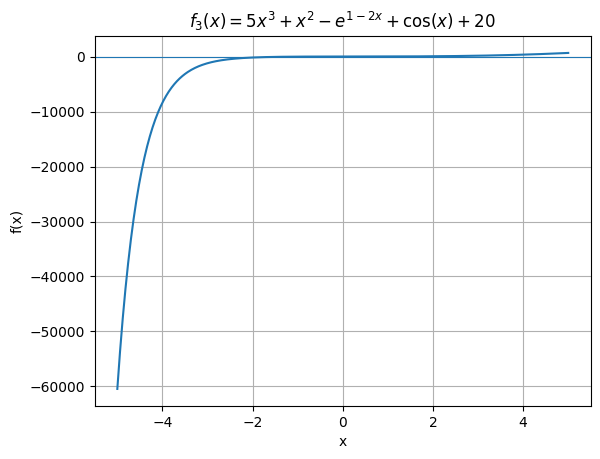

Função: $5x^3+x^2-e^{1-2x}+\cos(x)+20$


,Método,Raiz,Iterações,Convergiu,Tempo (s)
0,Bisseção,-0.929560,37,True,0.000246
1,Falsa Posição,1.568769,200,False,0.000780
2,Ponto Fixo,NaN,200,False,0.004307


In [12]:
f3_q4 = lambda x: 5*x**3 + x**2 - np.exp(1 - 2*x) + np.cos(x) + 20

x = np.linspace(-5, 5, 500)
plt.plot(x, f3_q4(x))
plt.axhline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f_3(x)=5x^3+x^2-e^{1-2x}+\cos(x)+20$")
plt.grid()
plt.show()

g3_q4 = lambda x: np.cbrt(
    (-x**2 + np.exp(1 - 2*x) - np.cos(x) - 20) / 5
)

tabela_f3 = comparar_metodos(
    f3_q4, g3_q4, -5, 5,
    r"$5x^3+x^2-e^{1-2x}+\cos(x)+20$"
)

## d) $f_4(x)=x\sin(x)+4$, com $x^*\in[1,5]$

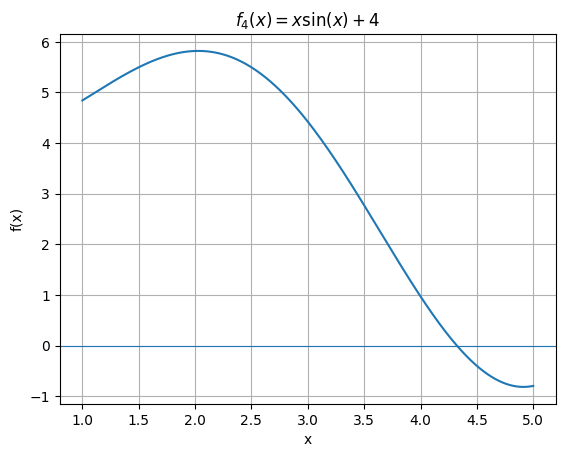

Função: $x\sin(x)+4$


,Método,Raiz,Iterações,Convergiu,Tempo (s)
0,Bisseção,4.32324,36.0,True,0.000119
1,Falsa Posição,4.32324,9.0,True,0.000025
2,Ponto Fixo,4.32324,NaN,True,0.001327


In [13]:
f4_q4 = lambda x: np.sin(x) * x + 4

x = np.linspace(1, 5, 500)
plt.plot(x, f4_q4(x))
plt.axhline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f_4(x)=x\sin(x)+4$")
plt.grid()
plt.show()

# Para esta função, usamos g(x)=x+alpha*f(x), com alpha pequeno.
alpha4 = 0.1
g4_q4 = lambda x: x + alpha4 * f4_q4(x)

tabela_f4 = comparar_metodos(
    f4_q4, g4_q4, 1, 5,
    r"$x\sin(x)+4$"
)

## e) $f_5(x)=(x-3)^5\ln(x)$, com $x^*\in[2,5]$

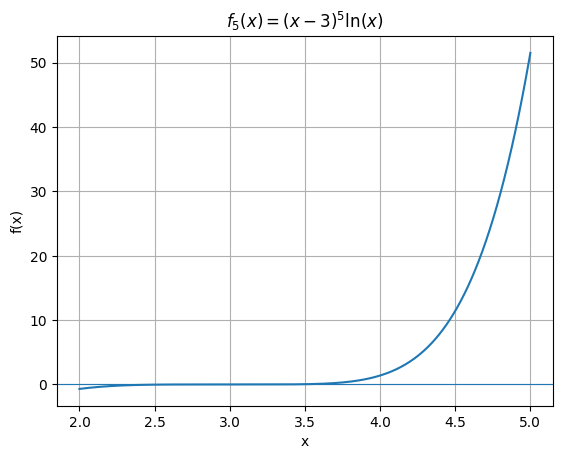

Função: $(x-3)^5\ln(x)$


,Método,Raiz,Iterações,Convergiu,Tempo (s)
0,Bisseção,3.00000,35,True,0.000146
1,Falsa Posição,2.59391,200,False,0.000246
2,Ponto Fixo,NaN,200,False,0.005273


In [14]:
f5_q4 = lambda x: (x - 3)**5 * np.log(x)

x = np.linspace(2, 5, 500)
plt.plot(x, f5_q4(x))
plt.axhline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f_5(x)=(x-3)^5\ln(x)$")
plt.grid()
plt.show()

alpha5 = 0.001
g5_q4 = lambda x: x - alpha5 * f5_q4(x)

tabela_f5 = comparar_metodos(
    f5_q4, g5_q4, 2, 5,
    r"$(x-3)^5\ln(x)$"
)

## f) $f_6(x)=x^{10}-1$, com $x^*\in[0.8,1.2]$

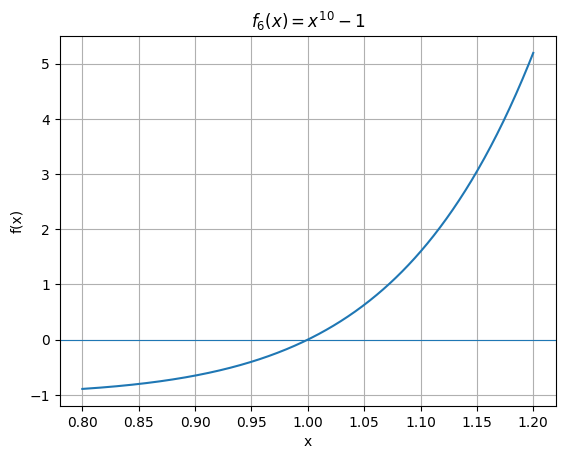

Função: $x^{10}-1$


,Método,Raiz,Iterações,Convergiu,Tempo (s)
0,Bisseção,1.0,1.0,True,0.000077
1,Falsa Posição,1.0,50.0,True,0.000017
2,Ponto Fixo,1.0,NaN,True,0.000789


In [15]:
f6_q4 = lambda x: x**10 - 1

x = np.linspace(0.8, 1.2, 500)
plt.plot(x, f6_q4(x))
plt.axhline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f_6(x)=x^{10}-1$")
plt.grid()
plt.show()

alpha6 = 0.05
g6_q4 = lambda x: x - alpha6 * f6_q4(x)

tabela_f6 = comparar_metodos(
    f6_q4, g6_q4, 0.8, 1.2,
    r"$x^{10}-1$"
)

## Tabela de Comparação Final

In [16]:
tabelas = {
    "f1": tabela_f1,
    "f2": tabela_f2,
    "f3": tabela_f3,
    "f4": tabela_f4,
    "f5": tabela_f5,
    "f6": tabela_f6,
}

linhas = []

for nome, tabela in tabelas.items():
    for _, row in tabela.iterrows():
        linhas.append({
            "Função": nome,
            "Método": row["Método"],
            "Raiz": row["Raiz"],
            "Iterações": row["Iterações"],
            "Convergiu": row["Convergiu"],
            "Tempo (s)": row["Tempo (s)"],
        })

tabela_final = pd.DataFrame(linhas)

tabela_final

,Função,Método,Raiz,Iterações,Convergiu,Tempo (s)
0,f1,Bisseção,1.492879,35.0,True,0.000750
1,f1,Falsa Posição,1.492879,78.0,True,0.000038
2,f1,Ponto Fixo,-1.300384,NaN,True,0.001560
3,f2,Bisseção,2.000000,36.0,True,0.000096
4,f2,Falsa Posição,1.714409,200.0,False,0.000059
5,f2,Ponto Fixo,NaN,200.0,False,0.007514
6,f3,Bisseção,-0.929560,37.0,True,0.000246
7,f3,Falsa Posição,1.568769,200.0,False,0.000780
8,f3,Ponto Fixo,NaN,200.0,False,0.004307
9,f4,Bisseção,4.323240,36.0,True,0.000119
